# TTC Merged GTFS EDA

Project:  TTC-Pulse <br>
Author: Omkumar M. Patel <br>
Github: https://github.com/LaeekAhmed/TTC-delay-analytics/

## Setup/Libraries

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
project = Path.cwd()
dataset = project / '01_gtfs_merged'
output = project / 'gtfs_eda_outputs'
output.mkdir(exist_ok=True)
plots = output / 'plots'
plots.mkdir(exist_ok=True)

# Set display options for pandas
# This will allow us to see more columns and wider content when we print DataFrames.
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

## Load the GTFS tables
GTFS identifiers are loaded as strings so keys like `route_id`, `trip_id`, `stop_id`, and `shape_id` are preserved exactly.

In [17]:
#read gtfs files
def read_gtfs(name: str) -> pd.DataFrame: # Reads a GTFS file into a pandas DataFrame.
    return pd.read_csv(dataset / f'{name}.txt', dtype=str, low_memory=False)

agency = read_gtfs('agency')
calendar = read_gtfs('calendar')
calendar_dates = read_gtfs('calendar_dates')
routes = read_gtfs('routes')
shapes = read_gtfs('shapes')
stop_times = read_gtfs('stop_times')
stops = read_gtfs('stops')
trips = read_gtfs('trips')

GTFS_og = {
    'agency': agency,
    'calendar': calendar,
    'calendar_dates': calendar_dates,
    'routes': routes,
    'shapes': shapes,
    'stop_times': stop_times,
    'stops': stops,
    'trips': trips
}

In [18]:
for column, df in GTFS_og.items():
    print(df.columns)

Index(['agency_id', 'agency_name', 'agency_url', 'agency_timezone',
       'agency_lang', 'agency_phone', 'agency_fare_url', 'agency_email',
       'cemv_support'],
      dtype='str')
Index(['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday',
       'saturday', 'sunday', 'start_date', 'end_date'],
      dtype='str')
Index(['service_id', 'date', 'exception_type'], dtype='str')
Index(['route_id', 'agency_id', 'route_short_name', 'route_long_name',
       'route_desc', 'route_type', 'route_url', 'route_color',
       'route_text_color'],
      dtype='str')
Index(['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence',
       'shape_dist_traveled'],
      dtype='str')
Index(['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence',
       'stop_headsign', 'pickup_type', 'drop_off_type', 'shape_dist_traveled',
       'timepoint'],
      dtype='str')
Index(['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat',
       'stop_lon', 'zone_id', 's

#### code/value - Og Description --> TTC Context <br>
0 - Tram, Streetcar, Light rail. Any light rail or street level system within a metropolitan area. --> Streetcar <br>
1 - Subway, Metro. Any underground rail system within a metropolitan area. --> Subway <br>
3 - Bus. Used for short- and long-distance bus routes. --> Bus

File and Attributes Info: https://gtfs.org/documentation/schedule/reference/#routestxt

In [20]:
#converting imp/relevant columns to appropriate data types for analysis.
routes['route_type'] = pd.to_numeric(routes['route_type'], errors='coerce')
trips['direction_id'] = pd.to_numeric(trips['direction_id'], errors='coerce')
stop_times['stop_sequence'] = pd.to_numeric(stop_times['stop_sequence'], errors='coerce')
shapes['shape_pt_sequence'] = pd.to_numeric(shapes['shape_pt_sequence'], errors='coerce')
calendar['start_date'] = pd.to_datetime(calendar['start_date'], format='%Y%m%d', errors='coerce')
calendar['end_date'] = pd.to_datetime(calendar['end_date'], format='%Y%m%d', errors='coerce')
calendar_dates['date'] = pd.to_datetime(calendar_dates['date'], format='%Y%m%d', errors='coerce')

GTFS = {
    'agency': agency,
    'calendar': calendar,
    'calendar_dates': calendar_dates,
    'routes': routes,
    'shapes': shapes,
    'stop_times': stop_times,
    'stops': stops,
    'trips': trips,
}

In [21]:
for k,v in GTFS.items():
    print(f"{k}: {v.shape}")

agency: (1, 9)
calendar: (8, 10)
calendar_dates: (7, 3)
routes: (229, 9)
shapes: (1025672, 5)
stop_times: (4249149, 10)
stops: (9417, 12)
trips: (133665, 9)


In [22]:
print(len(routes))
GTFS.get('routes').head()

229


,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color
0,10,1,10,Van Horne,NaN,3,NaN,ED1C24,FFFFFF
1,100,1,100,Flemingdon Park,NaN,3,NaN,ED1C24,FFFFFF
2,101,1,101,Downsview Park,NaN,3,NaN,ED1C24,FFFFFF
3,102,1,102,Markham Rd,NaN,3,NaN,ED1C24,FFFFFF
4,103,1,103,Mount Pleasant North,NaN,3,NaN,ED1C24,FFFFFF


In [23]:
routes.route_type.value_counts(dropna=False)

route_type
3    207
0     19
1      3
Name: count, dtype: int64

In [24]:
routes.isna().sum()
# Thus route_desc and route_url are completely empty and can be dropped without losing any information. 
# route_color, route_text_color are not useful for our analysis and can be dropped as well. 

route_id              0
agency_id             0
route_short_name      0
route_long_name       0
route_desc          229
route_type            0
route_url           229
route_color           0
route_text_color      2
dtype: int64

In [25]:
#cleaned routes
routes_c = routes.drop(columns=['route_desc', 'route_url', 'route_color', 'route_text_color'], inplace=False)

In [27]:
routes_c.route_long_name.value_counts(dropna=False)

route_long_name
Bathurst                 3
Kingston Rd              2
Coxwell                  2
Victoria Park            2
Don Mills                2
                        ..
East York                1
Etobicoke                1
Scarborough-Guildwood    1
Finch West Line          1
Eglinton Line            1
Name: count, Length: 199, dtype: int64

## Table-by-table profiling
To understand the row counts, column counts, and column names for each GTFS table.

In [28]:
profile_rows = []
for name, df in GTFS.items():
    profile_rows.append({
        'table_name': name,
        'row_count': len(df),
        'column_count': len(df.columns),
        'columns': ', '.join(df.columns),
    })
profile = pd.DataFrame(profile_rows).sort_values('table_name').reset_index(drop=True)
profile


,table_name,row_count,column_count,columns
0,agency,1,9,"agency_id, agency_name, agency_url, agency_timezone, agency_lang, agency_phone, agency_fare_url, agency_email, cemv_..."
1,calendar,8,10,"service_id, monday, tuesday, wednesday, thursday, friday, saturday, sunday, start_date, end_date"
2,calendar_dates,7,3,"service_id, date, exception_type"
3,routes,229,9,"route_id, agency_id, route_short_name, route_long_name, route_desc, route_type, route_url, route_color, route_text_c..."
4,shapes,1025672,5,"shape_id, shape_pt_lat, shape_pt_lon, shape_pt_sequence, shape_dist_traveled"
5,stop_times,4249149,10,"trip_id, arrival_time, departure_time, stop_id, stop_sequence, stop_headsign, pickup_type, drop_off_type, shape_dist..."
6,stops,9417,12,"stop_id, stop_code, stop_name, stop_desc, stop_lat, stop_lon, zone_id, stop_url, location_type, parent_station, stop..."
7,trips,133665,9,"trip_id, route_id, service_id, trip_headsign, trip_short_name, direction_id, block_id, shape_id, wheelchair_accessible"


## Step 5. Column completeness and uniqueness
This surfaces sparse fields, metadata-only fields, and fields that may not help Monday's analysis.

In [29]:
completeness_rows = []
for name, df in GTFS.items():
    for col in df.columns:
        nulls = int(df[col].isna().sum())
        completeness_rows.append({
            'table_name': name,
            'column_name': col,
            'null_count': nulls,
            'null_pct': round((nulls / len(df) * 100) if len(df) else 0, 4),
            'n_unique': int(df[col].nunique(dropna=True)),
        })
completeness = pd.DataFrame(completeness_rows)
completeness.sort_values(['table_name', 'null_pct', 'n_unique'], ascending=[True, False, True]).head(30)


,table_name,column_name,null_count,null_pct,n_unique
0,agency,agency_id,0,0.0000,1
1,agency,agency_name,0,0.0000,1
2,agency,agency_url,0,0.0000,1
3,agency,agency_timezone,0,0.0000,1
4,agency,agency_lang,0,0.0000,1
5,agency,agency_phone,0,0.0000,1
6,agency,agency_fare_url,0,0.0000,1
7,agency,agency_email,0,0.0000,1
8,agency,cemv_support,0,0.0000,1
17,calendar,start_date,0,0.0000,1


## Foreign-key style relationship checks
These checks verify the main GTFS connectivity: routes to trips, trips to stop_times, trips to shapes, trips to calendar, and stop_times to stops.

In [31]:
#let's add row count as well to the checks for better context.
shape_ids = set(shapes['shape_id'].dropna())
checks = pd.DataFrame([
    {
        'relationship': 'trips.route_id -> routes.route_id',
        'missing_fk_count': int((~trips['route_id'].isin(routes['route_id'])).sum()),
        'row_count': len(trips)

    },
    {
        'relationship': 'trips.service_id -> calendar.service_id',
        'missing_fk_count': int((~trips['service_id'].isin(calendar['service_id'])).sum()),
        'row_count': len(trips)
    },
    {
        'relationship': 'trips.shape_id -> shapes.shape_id',
        'missing_fk_count': int((~trips['shape_id'].isin(shape_ids)).sum()),
        'row_count': len(trips)
    },
    {
        'relationship': 'stop_times.trip_id -> trips.trip_id',
        'missing_fk_count': int((~stop_times['trip_id'].isin(trips['trip_id'])).sum()),
        'row_count': len(stop_times)
    },
    {
        'relationship': 'stop_times.stop_id -> stops.stop_id',
        'missing_fk_count': int((~stop_times['stop_id'].isin(stops['stop_id'])).sum()),
        'row_count': len(stop_times)
    },
])
checks


,relationship,missing_fk_count,row_count
0,trips.route_id -> routes.route_id,0,133665
1,trips.service_id -> calendar.service_id,0,133665
2,trips.shape_id -> shapes.shape_id,978,133665
3,stop_times.trip_id -> trips.trip_id,0,4249149
4,stop_times.stop_id -> stops.stop_id,0,4249149


## Clarifying the shape relationship exception
The `shape_id` relationship is not fully complete, so we check whether those cases are broken references or just blanks.

In [33]:
unmatched_shapes = trips.loc[~trips['shape_id'].isin(shape_ids), ['trip_id', 'route_id', 'shape_id', 'direction_id']]
print('Unmatched shape rows:', len(unmatched_shapes))
print('Blank shape_id rows:', int(trips['shape_id'].fillna('').eq('').sum()))
print('Nonblank unmatched shape rows:', int(unmatched_shapes['shape_id'].fillna('').ne('').sum()))
unmatched_shapes.head()


Unmatched shape rows: 978
Blank shape_id rows: 978
Nonblank unmatched shape rows: 0


,trip_id,route_id,shape_id,direction_id
132687,131883119,5,NaN,0
132688,131883120,5,NaN,1
132689,131883121,5,NaN,0
132690,131883122,5,NaN,1
132691,131883123,5,NaN,0


In [ ]:
# Thus, there are 978 rows in trips with shape_id values that do not match any shape_id in shapes. 
# All of these rows have non-blank shape_id values, so they are not just missing data -
# they reference shape_ids that are not present in the shapes table. This indicates a data quality issue where trips are referencing shapes that do not exist in the dataset.

## Route and mode understanding
This shows how many TTC routes exist by mode and which routes have the largest trip volume.

In [36]:
route_type_counts = routes.groupby('route_type').size().reset_index(name='route_count').sort_values('route_count', ascending=False)
trips_per_route = trips.groupby('route_id').size().reset_index(name='trip_count').merge(
    routes[['route_id', 'route_short_name', 'route_long_name', 'route_type']],
    on='route_id',
    how='left'
).sort_values('trip_count', ascending=False)

route_type_counts, trips_per_route.head(15)


(   route_type  route_count
 2           3          207
 0           0           19
 1           1            3,
     route_id  trip_count route_short_name        route_long_name  route_type
 139      504        3244              504                   King           0
 159       63        2533               63              Ossington           3
 132       47        2393               47              Lansdowne           3
 0          1        2276                1  Yonge-University Line           1
 64         2        2206                2    Bloor-Danforth Line           1
 118        4        1761                4          Sheppard Line           1
 149       52        1749               52          Lawrence West           3
 146      510        1733              510                Spadina           0
 4        102        1530              102             Markham Rd           3
 192      900        1525              900        Airport Express           3
 107       36        1515    

route_type
3    207
0     19
1      3
Name: count, dtype: int64


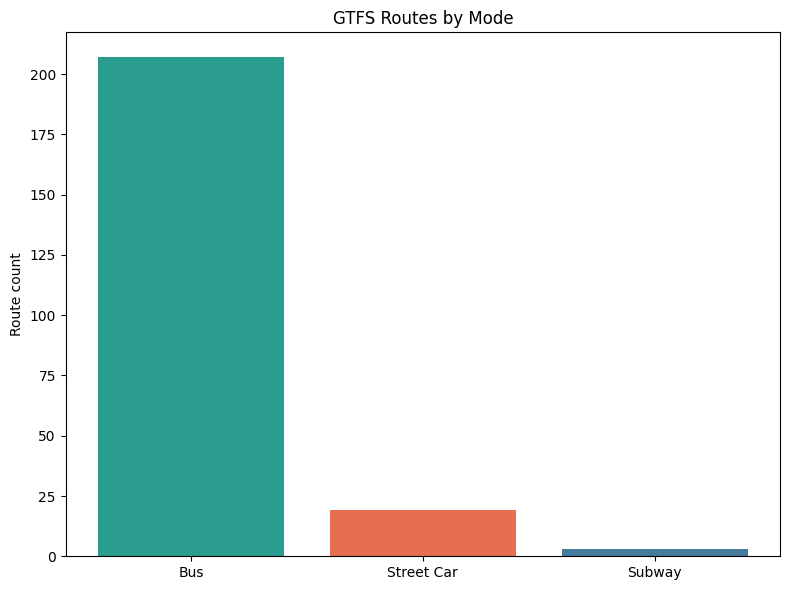

In [48]:
#update the bar chart to use route_type_label 
route_type_labels = {
    0: 'Street Car',
    1: 'Subway',
    3: 'Bus',
}

print(routes['route_type'].value_counts(dropna=False))
routes['route_type_labels'] = routes['route_type'].map(route_type_labels)
route_type_counts = routes.groupby('route_type_labels').size().reset_index(name='route_count').sort_values('route_count', ascending=False)
plt.figure(figsize=(8, 6))
plt.bar(route_type_counts['route_type_labels'], route_type_counts['route_count'], color=['#2a9d8f', '#e76f51', '#457b9d'])
plt.title('GTFS Routes by Mode')
plt.ylabel('Route count')
plt.tight_layout()
plt.show()

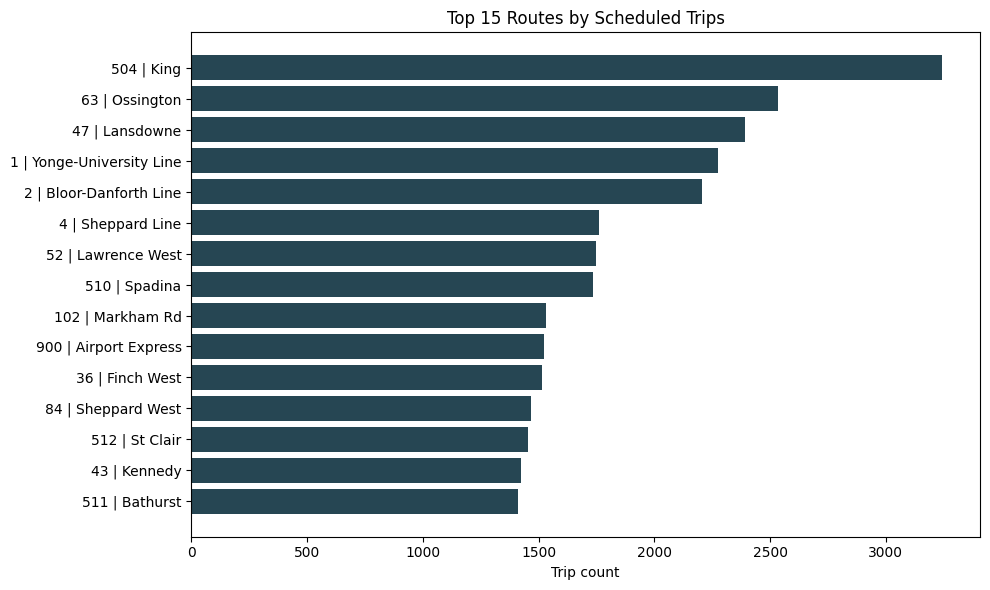

In [49]:
plot_routes = trips_per_route.head(15).copy()
plot_routes['label'] = plot_routes['route_short_name'].fillna('NA') + ' | ' + plot_routes['route_long_name'].fillna('')
plt.figure(figsize=(10, 6))
plt.barh(plot_routes['label'][::-1], plot_routes['trip_count'][::-1], color='#264653')
plt.title('Top 15 Routes by Scheduled Trips')
plt.xlabel('Trip count')
plt.tight_layout()
plt.show()


## Stop and geometry understanding
This helps explain how stops and shapes contribute to the bridge layer and to any later map-based work.

In [50]:
stop_service = stop_times.groupby('stop_id').agg(
    trip_visits=('trip_id', 'count'),
    distinct_trips=('trip_id', 'nunique'),
    min_stop_sequence=('stop_sequence', 'min'),
    max_stop_sequence=('stop_sequence', 'max')
).reset_index().merge(
    stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station']],
    on='stop_id',
    how='left'
).sort_values('trip_visits', ascending=False)

shape_summary = shapes.groupby('shape_id').agg(
    point_count=('shape_pt_sequence', 'count'),
    max_shape_sequence=('shape_pt_sequence', 'max')
).reset_index().sort_values('point_count', ascending=False)

stop_service.head(15), shape_summary.head(15)


(     stop_id  trip_visits  distinct_trips  min_stop_sequence  \
 3935   42916         4699            4699                  7   
 3687   42330         4090            4090                  5   
 3825   42568         3507            3507                  2   
 3610     416         3459            3459                  2   
 6412    6857         3458            3458                  5   
 3560   41043         2669            2669                  4   
 4137    4415         2522            2522                  3   
 8936    9516         2493            2493                  1   
 3310    3850         2490            2490                  1   
 6316    6758         2457            2457                  3   
 3557   41040         2457            2457                  2   
 3558   41041         2457            2457                  4   
 3559   41042         2448            2448                  3   
 2493    2305         2295            2295                  6   
 3892    4283         222

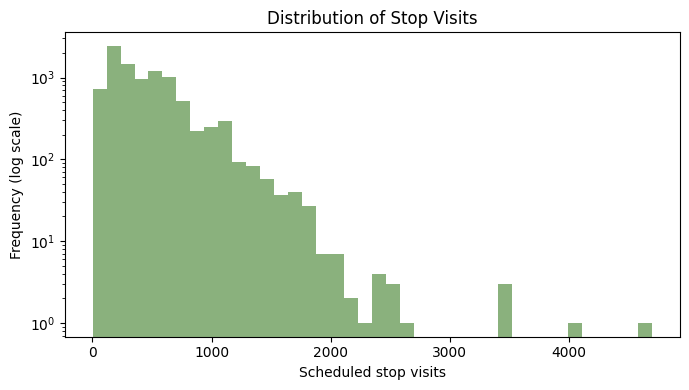

In [51]:
vals = stop_service['trip_visits'].dropna().astype(float)
plt.figure(figsize=(7, 4))
plt.hist(vals, bins=40, color='#8ab17d')
plt.yscale('log')
plt.title('Distribution of Stop Visits')
plt.xlabel('Scheduled stop visits')
plt.ylabel('Frequency (log scale)')
plt.tight_layout()
plt.show()


## calendar understanding (Try)
This shows how service operates across weekdays and how service spans are defined.

In [52]:
service_summary = calendar.copy()
service_summary['service_days_per_week'] = service_summary[['monday','tuesday','wednesday','thursday','friday','saturday','sunday']].fillna('0').astype(int).sum(axis=1)
service_summary['service_span_days'] = (service_summary['end_date'] - service_summary['start_date']).dt.days
service_summary[['service_id', 'service_days_per_week', 'service_span_days', 'start_date', 'end_date']]


,service_id,service_days_per_week,service_span_days,start_date,end_date
0,1,5,34,2026-02-08,2026-03-14
1,2,1,34,2026-02-08,2026-03-14
2,3,1,34,2026-02-08,2026-03-14
3,4,0,34,2026-02-08,2026-03-14
4,4401,3,34,2026-02-08,2026-03-14
5,4501,2,34,2026-02-08,2026-03-14
6,5,1,34,2026-02-08,2026-03-14
7,7001,3,34,2026-02-08,2026-03-14


## Route-stop (Bridge factor)
Kinda bridge layer possibility. Merging/joining tables to show how routes, trips, stops, and directions connect.

In [56]:
route_stop_bridge = stop_times[['trip_id', 'stop_id', 'stop_sequence']].merge(
    trips[['trip_id', 'route_id', 'direction_id']],
    on='trip_id',
    how='left'
).merge(
    routes[['route_id', 'route_short_name', 'route_long_name',]],
    on='route_id',
    how='left'
).merge(
    stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']],
    on='stop_id',
    how='left'
)

route_stop_bridge_summary = route_stop_bridge.groupby(
    ['route_id', 'route_short_name', 'route_long_name', 'direction_id', 'stop_id', 'stop_name', 'stop_lat', 'stop_lon'],
    dropna=False
).agg(
    trip_count_serving_stop=('trip_id', 'nunique'),
    min_stop_sequence=('stop_sequence', 'min'),
    max_stop_sequence=('stop_sequence', 'max')
).reset_index().sort_values('trip_count_serving_stop', ascending=False)

route_stop_bridge_summary.head(20)


,route_id,route_short_name,route_long_name,direction_id,stop_id,stop_name,stop_lat,stop_lon,trip_count_serving_stop,min_stop_sequence,max_stop_sequence
11607,504,504,King,0,214,King St East at Sackville St,43.654602,-79.360165,1604,3,15
11700,504,504,King,1,751,King St East at Parliament St,43.652556,-79.363371,1578,2,36
11694,504,504,King,1,5762,King St East at Sumach St,43.65528,-79.358705,1578,4,38
11692,504,504,King,1,5587,King St East at Sackville St,43.6543,-79.360379,1578,3,37
13343,63,63,Ossington,1,3834,Ossington Station at Bus Bay 2,43.662271,-79.426546,1244,1,14
11130,47,47,Lansdowne,1,7623,Lansdowne Ave at Wade Ave - Lansdowne Station,43.659077,-79.442882,1199,1,12
11105,47,47,Lansdowne,0,8607,Lansdowne Ave at Wade Ave - Lansdowne Station,43.659323,-79.443165,1194,1,19
39,1,1,Yonge-University Line,1,13791,York Mills Station - Northbound Platform,43.744448,-79.406191,1132,1,35
38,1,1,Yonge-University Line,1,13790,North York Centre Station - Northbound Platform,43.768547,-79.412592,1132,3,37
65,1,1,Yonge-University Line,1,13859,Sheppard-Yonge Station - Northbound Platform,43.761648,-79.410891,1132,2,36


## reusable outputs 
(With help of pplx) This cell exports the key summary tables and plots so they can be reused outside the notebook.

route_type
3    207
0     19
1      3
Name: count, dtype: int64


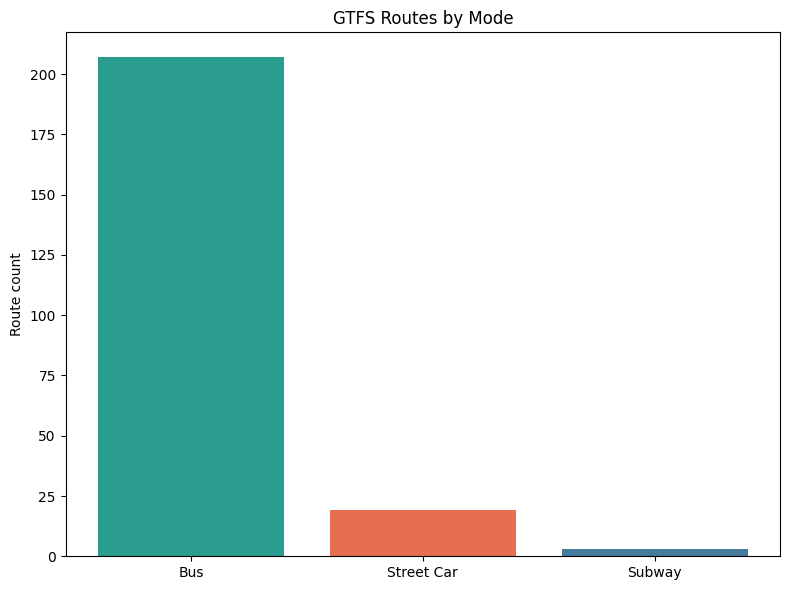

['gtfs_column_completeness.csv',
 'gtfs_relationship_checks.csv',
 'gtfs_route_stop_bridge_sample.csv',
 'gtfs_route_type_counts.csv',
 'gtfs_service_calendar_summary.csv',
 'gtfs_shape_summary.csv',
 'gtfs_stop_service_summary.csv',
 'gtfs_table_profile.csv',
 'gtfs_trips_per_route.csv',
 'plots']

In [58]:
profile.to_csv(output / 'gtfs_table_profile.csv', index=False)
completeness.to_csv(output / 'gtfs_column_completeness.csv', index=False)
checks.to_csv(output / 'gtfs_relationship_checks.csv', index=False)
route_type_counts.to_csv(output / 'gtfs_route_type_counts.csv', index=False)
trips_per_route.to_csv(output / 'gtfs_trips_per_route.csv', index=False)
stop_service.to_csv(output / 'gtfs_stop_service_summary.csv', index=False)
shape_summary.to_csv(output / 'gtfs_shape_summary.csv', index=False)
service_summary.to_csv(output / 'gtfs_service_calendar_summary.csv', index=False)
route_stop_bridge_summary.head(20000).to_csv(output / 'gtfs_route_stop_bridge_sample.csv', index=False)

# Save plots
#update the bar chart to use route_type_label 
route_type_labels = {
    0: 'Street Car',
    1: 'Subway',
    3: 'Bus',
}

print(routes['route_type'].value_counts(dropna=False))
routes['route_type_labels'] = routes['route_type'].map(route_type_labels)
route_type_counts = routes.groupby('route_type_labels').size().reset_index(name='route_count').sort_values('route_count', ascending=False)
plt.figure(figsize=(8, 6))
plt.bar(route_type_counts['route_type_labels'], route_type_counts['route_count'], color=['#2a9d8f', '#e76f51', '#457b9d'])
plt.title('GTFS Routes by Mode')
plt.ylabel('Route count')
plt.tight_layout()
plt.show()

plot_routes = trips_per_route.head(15).copy()
plot_routes['label'] = plot_routes['route_short_name'].fillna('NA') + ' | ' + plot_routes['route_long_name'].fillna('')
plt.figure(figsize=(10, 6))
plt.barh(plot_routes['label'][::-1], plot_routes['trip_count'][::-1], color='#264653')
plt.title('Top 15 Routes by Scheduled Trips')
plt.xlabel('Trip count')
plt.tight_layout()
plt.savefig(plots / 'top_routes_by_trips.png', dpi=160)
plt.close()

vals = stop_service['trip_visits'].dropna().astype(float)
plt.figure(figsize=(7, 4))
plt.hist(vals, bins=40, color='#8ab17d')
plt.yscale('log')
plt.title('Distribution of Stop Visits')
plt.xlabel('Scheduled stop visits')
plt.ylabel('Frequency (log scale)')
plt.tight_layout()
plt.savefig(plots / 'stop_visit_distribution.png', dpi=160)
plt.close()

sorted([p.name for p in output.iterdir()])


## Findings/Conclusion

In [53]:
primary = ['routes', 'trips', 'stop_times', 'stops', 'calendar']
secondary = ['shapes', 'calendar_dates']
low_priority = ['agency', 'agency.cemv_support']

pd.DataFrame({
    'primary': pd.Series(primary),
    'secondary': pd.Series(secondary),
    'low_priority': pd.Series(low_priority),
})


,primary,secondary,low_priority
0,routes,shapes,agency
1,trips,calendar_dates,agency.cemv_support
2,stop_times,NaN,NaN
3,stops,NaN,NaN
4,calendar,NaN,NaN


- The core GTFS spine is `routes -> trips -> stop_times -> stops`.
- `shapes` is valuable for map/path logic but not required for the first timetable bridge.
- `calendar` matters for service context; `calendar_dates` is small but useful for exact exceptions.
- `stops.parent_station` and `stops.location_type` are blank, so static GTFS alone does not give a reliable subway station hierarchy.
- So we can focus on route, stop, service calendar context, and the derived route-stop bridge view.